[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ScriptsRemote/Transcend_SummerSchool/blob/main/Day4_LULC_and_Climate_with_RS/03_training_mapping_and_accuracy.ipynb)

# Day 4 - Land Use / Land Cover & Climate with RS
## Session 3: Training, Mapping and Accuracy

| | |
|---|---|
| **Fecha / Date** | 2026-10-15 (Thursday / Jueves) |
| **Horario / Time** | 14:00 - 15:30 |
| **Entidad / Entity** | UoM |
| **Instructores / Instructors** | Christhian, Gustavo |

### Contenido / Content

> From the model to the product: **K-fold validation** (random and spatial), final model, thematic
> map, area per class and **export**; **irrigated versus rainfed** agriculture with dry/wet season
> signatures and map algebra; **change detection** with MapBiomas.

### Objetivos de aprendizaje / Learning objectives

- [ ] Use K-fold cross-validation to choose the input of the classifier, and explain why a
      **spatial** K-fold gives a more honest accuracy than a random one
- [ ] Train the final model with all samples, produce the thematic map, compute the area per
      class and export the result (GeoTIFF, asset, CSV)
- [ ] Separate irrigated and rainfed agriculture from their NDVI signature in the dry and wet
      season
- [ ] Build a "from - to" change matrix with map algebra

### Datos necesarios / Required data

- Landsat 8/9 C2 L2, Sentinel-2 SR, NASADEM and **MapBiomas Bolivia Collection 3** (Earth Engine)
- `Assets/Day4/copacabana_samples.geojson` (same samples as sessions 1 and 2)

### Lo que ya vimos / What is assumed

Session 1: classifiers and the confusion matrix. Session 2: dry and wet season mosaics, and the
lesson that **one random 70/30 split is not enough** to compare inputs. This session starts from
there.

### Two study areas

| Area | Used for |
|---|---|
| **Copacabana** (same as sessions 1 and 2) | K-fold, final model, map, area, export |
| **Irrigation area** (east shore of the lake) | irrigated vs rainfed, change detection |

---

## 3.1 - Setup

In [23]:
# Libraries (uncomment the pip line on a fresh runtime, e.g. Google Colab)
#%pip install -q earthengine-api geemap scikit-learn

import os
import ee                          # Google Earth Engine API
import geemap                      # interactive maps for Earth Engine
import pandas as pd                # tables (DataFrames)
import matplotlib.pyplot as plt    # charts

# scikit-learn: Random Forest and K-fold cross-validation
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold, cross_val_score

In [24]:
# Authenticate and initialise Earth Engine
# >>> REPLACE with your own Cloud project id <<<
EE_PROJECT = "ee-christhianscunha"

ee.Authenticate()
ee.Initialize(project=EE_PROJECT)

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


In [ ]:
# Copacabana (sessions 1 and 2): classification, validation and export
REGION = ee.Geometry.Polygon(
    [[[-69.1010932684908, -16.14842858486395],
      [-69.1010932684908, -16.17175891406604],
      [-69.06075284490682, -16.17175891406604],
      [-69.06075284490682, -16.14842858486395]]], None, False)

# Irrigation area (east shore of the lake): irrigated vs rainfed and change detection
IRR_REGION = ee.Geometry.Polygon(
    [[[-68.70649599980511, -16.007559642081016],
      [-68.70649599980511, -16.06431337741235],
      [-68.62581515263714, -16.06431337741235],
      [-68.62581515263714, -16.007559642081016]]], None, False)

Map = geemap.Map()
Map.centerObject(REGION.union(IRR_REGION, maxError=1), 10)
Map.add_basemap("SATELLITE")
Map.addLayer(REGION, {"color": "red"}, "Copacabana")
Map.addLayer(IRR_REGION, {"color": "yellow"}, "Irrigation area")
Map

Map(center=[-16.05715238619831, -68.73679819491656], controls=(WidgetControl(options=['position', 'transparent…

### Data cube functions (from Day 3 and session 2)

The same functions as before. `seasonal_mosaic` now receives the **region** as an argument,
because we use it in the two areas.

In [26]:
def mask_clouds(image):
    # QA_PIXEL bits 1 (dilated cloud), 2 (cirrus), 3 (cloud) and 4 (cloud shadow)
    cloud_bits = (1 << 1) | (1 << 2) | (1 << 3) | (1 << 4)
    clear = image.select("QA_PIXEL").bitwiseAnd(cloud_bits).eq(0)
    return image.updateMask(clear)


def scale_and_rename(image):
    # Collection 2 scale factor -> surface reflectance, and readable band names
    optical = image.select(["SR_B2", "SR_B3", "SR_B4", "SR_B5", "SR_B6", "SR_B7"])
    optical = optical.multiply(0.0000275).add(-0.2)
    return optical.rename(["Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2"])


def add_indices(image):
    ndvi = image.normalizedDifference(["NIR", "Red"]).rename("NDVI")
    ndwi = image.normalizedDifference(["Green", "NIR"]).rename("NDWI")
    ndmi = image.normalizedDifference(["NIR", "SWIR1"]).rename("NDMI")
    evi = image.expression(
        "2.5 * (NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1)",
        {"NIR": image.select("NIR"), "RED": image.select("Red"), "BLUE": image.select("Blue")},
    ).rename("EVI")
    msavi = image.expression(
        "(2 * NIR + 1 - sqrt((2 * NIR + 1) ** 2 - 8 * (NIR - RED))) / 2",
        {"NIR": image.select("NIR"), "RED": image.select("Red")},
    ).rename("MSAVI")
    return image.addBands([ndvi, msavi, evi, ndwi, ndmi])


def seasonal_mosaic(region, start, end, max_cloud):
    # Landsat 8 + 9 of one period and one region: filter, clean, scale, add indices, median
    collection = (ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
                    .merge(ee.ImageCollection("LANDSAT/LC09/C02/T1_L2"))
                    .filterBounds(region)
                    .filterDate(start, end)
                    .filter(ee.Filter.lt("CLOUD_COVER", max_cloud))
                    .map(mask_clouds)
                    .map(scale_and_rename)
                    .map(add_indices))
    return collection.median().clip(region)

In [27]:
# Dry and wet season of the 2023/24 agricultural year (Copacabana)
dry = seasonal_mosaic(REGION, "2024-05-01", "2024-10-01", max_cloud=30)
wet = seasonal_mosaic(REGION, "2023-11-01", "2024-05-01", max_cloud=60)

# Stack with both seasons, ΔNDVI and terrain (as in session 2)
dry_s = dry.rename(dry.bandNames().map(lambda b: ee.String(b).cat("_dry")))
wet_s = wet.rename(wet.bandNames().map(lambda b: ee.String(b).cat("_wet")))
delta_ndvi = wet.select("NDVI").subtract(dry.select("NDVI")).rename("dNDVI")
elevation = ee.Image("NASA/NASADEM_HGT/001").select("elevation")
slope = ee.Terrain.slope(elevation).rename("slope")

stack = dry_s.addBands([wet_s, delta_ndvi, elevation, slope]).toFloat()

# The three candidate inputs
DRY_BANDS = dry_s.bandNames().getInfo()
WET_BANDS = wet_s.bandNames().getInfo()
INPUTS = {
    "Dry": DRY_BANDS + ["elevation", "slope"],
    "Wet": WET_BANDS + ["elevation", "slope"],
    "Dry + wet": DRY_BANDS + WET_BANDS + ["dNDVI", "elevation", "slope"],
}

In [28]:
# Samples (same file as sessions 1 and 2)
SAMPLES_FILE = "../Assets/Day4/copacabana_samples.geojson"
SAMPLES_URL = ("https://raw.githubusercontent.com/ScriptsRemote/Transcend_SummerSchool/"
               "main/Assets/Day4/copacabana_samples.geojson")   # used in Colab
CLASS_PROPERTY = "class"
NAME_PROPERTY = "class_name"

samples = geemap.geojson_to_ee(SAMPLES_FILE if os.path.exists(SAMPLES_FILE) else SAMPLES_URL)

classes = (geemap.ee_to_df(samples)[[CLASS_PROPERTY, NAME_PROPERTY]]
           .drop_duplicates().sort_values(CLASS_PROPERTY).reset_index(drop=True))
CLASS_CODES = classes[CLASS_PROPERTY].astype(int).tolist()
CLASS_NAMES = classes[NAME_PROPERTY].tolist()
PALETTE = ["#2c7bb6", "#a21616", "#d8b365", "#2ae01a", "#cc7218"]
vis_classes = {"min": min(CLASS_CODES), "max": max(CLASS_CODES), "palette": PALETTE}

classes

,class,class_name
0,1,water
1,2,urban
2,3,agriculture
3,4,vegetation
4,5,soil


---

## 3.2 - K-fold cross-validation: let the data choose the input

In session 2 a single random 70/30 split could not tell which input was best - the test set
was too small. **K-fold cross-validation** uses all samples for testing:

1. split the samples into **k folds** (here k = 5);
2. train on 4 folds and test on the 5th;
3. repeat 5 times, so every sample is tested once;
4. report the **mean ± standard deviation** of the accuracy.

### Random folds versus spatial folds

Our samples come from a **100 m grid inside a few polygons**. With **random** folds, a test point
almost always has a training neighbour 100 m away - nearly the same pixel - and the accuracy is
**too optimistic**. With **spatial folds**, the area is cut into blocks and every point of a
block goes to the same fold: the model is tested on places it has not seen (Roberts et al.,
2017).

> Why blocks and not polygons? Grouping by `polygon_id` would be ideal, but our file has only
> **one polygon of urban** and two of agriculture and soil - with 5 folds, some folds would have
> no urban at all. Blocks of 300 m (three times the sample spacing) keep every class in several
> folds.

### What runs where

Up to here **nothing was classified** - we only built the stack (dry, wet, ΔNDVI, terrain) and
loaded the samples. The K-fold does not produce maps: it only **tests models on the samples**.

| Step | Where | What happens | Result |
|---|---|---|---|
| 1 | Earth Engine | `sampleRegions` reads the 25 bands of the stack under each of the 488 samples | **one table** (rows = pixels, columns = bands + class) |
| 2 | scikit-learn | 3 inputs × 5 folds = **15 Random Forests** trained and tested on that table | mean ± std accuracy of each input |
| 3 | Earth Engine (section 3.3) | **one** Random Forest with the winning input and all samples classifies the image | the final map |

The table is small (a few hundred rows), so the 15 models run in seconds on your computer.
Classifying the image - millions of pixels - stays in Earth Engine.

In [29]:
# 1. Earth Engine: pixel values of ALL bands under every sample, with the coordinates
pixels = stack.sampleRegions(collection=samples,
                             properties=[CLASS_PROPERTY, "longitude", "latitude"],
                             scale=30, tileScale=4)

# 2. To pandas; remove rows with missing values (e.g. clouds in the wet mosaic)
df = geemap.ee_to_df(pixels).dropna()

# 3. Spatial blocks of ~300 m (0.003 degrees): every point gets the id of its block
df["block"] = ((df["longitude"] // 0.003).astype(int).astype(str) + "_" +
               (df["latitude"] // 0.003).astype(int).astype(str))

print("Pixels:", len(df), "| spatial blocks:", df["block"].nunique())
df.groupby(CLASS_PROPERTY)["block"].nunique().rename("blocks per class")

Pixels: 269 | spatial blocks: 52


class
1    19
2    11
3    15
4     7
Name: blocks per class, dtype: int64

In [30]:
# Same Random Forest for every test (100 trees, as in Earth Engine)
rf_sk = RandomForestClassifier(n_estimators=100, random_state=42)

# Two ways of building the 5 folds
random_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
spatial_folds = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

y = df[CLASS_PROPERTY]


def kfold(bands, folds, groups=None):
    # Overall accuracy of the 5 folds
    return cross_val_score(rf_sk, df[bands], y, cv=folds, groups=groups, scoring="accuracy")


# Run both K-folds for each of the three inputs
cv = {}
for name, bands in INPUTS.items():
    spatial = kfold(bands, spatial_folds, groups=df["block"])
    cv[name] = {"Random K-fold (mean)": kfold(bands, random_folds).mean(),
                "Spatial K-fold (mean)": spatial.mean(),
                "Spatial K-fold (std)": spatial.std()}
cv = pd.DataFrame(cv).T

cv.round(3)

,Random K-fold (mean),Spatial K-fold (mean),Spatial K-fold (std)
Dry,0.981,0.981,0.012
Wet,0.974,0.970,0.019
Dry + wet,0.974,0.974,0.025


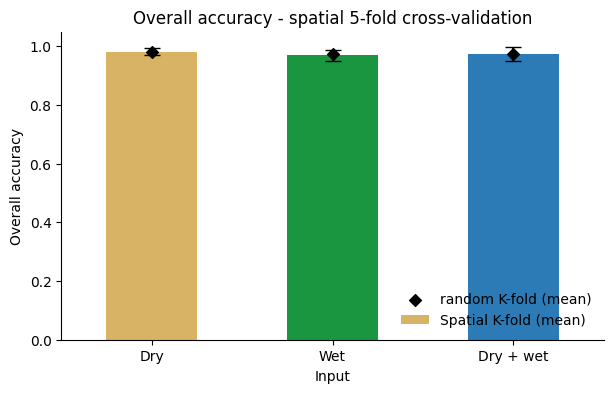

Input chosen by the spatial K-fold: Dry


In [31]:
# Mean ± std of the spatial K-fold for each input
ax = cv["Spatial K-fold (mean)"].plot.bar(yerr=cv["Spatial K-fold (std)"], capsize=6, rot=0,
                                          figsize=(7, 4), color=["#d8b365", "#1a9641", "#2c7bb6"])
ax.scatter(range(len(cv)), cv["Random K-fold (mean)"], color="black", marker="D", zorder=3,
           label="random K-fold (mean)")
ax.set_title("Overall accuracy - spatial 5-fold cross-validation")
ax.set_xlabel("Input")
ax.set_ylabel("Overall accuracy")
ax.set_ylim(0, 1.05)
ax.legend(frameon=False, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

# The input with the highest spatial K-fold accuracy is used for the final map
BEST = cv["Spatial K-fold (mean)"].idxmax()
print("Input chosen by the spatial K-fold:", BEST)

**How to read it.**

- The **black diamonds** (random folds) are almost always **higher** than the bars (spatial
  folds). That gap is the optimism caused by spatial autocorrelation.
- The **error bars** show how much the accuracy changes from fold to fold. If the bars of two
  inputs overlap, they are practically equivalent - choose the simpler one if you prefer.
- The input with the best spatial accuracy (`BEST`) goes to the final model.

---

## 3.3 - Final model, thematic map and area per class

After validation, the **final model is trained with all samples** - there is no reason to leave
data out any more. Its expected accuracy is the one estimated by the K-fold above; it cannot be
measured again with the same samples.

In [32]:
# Final Random Forest in Earth Engine: all samples, input chosen by the K-fold
bands = INPUTS[BEST]
rf_final = ee.Classifier.smileRandomForest(numberOfTrees=100, seed=42).train(
    features=pixels, classProperty=CLASS_PROPERTY, inputProperties=bands)

classified = stack.select(bands).classify(rf_final).rename("class")

# Post-processing: majority filter (3 x 3 pixels) removes isolated pixels ("salt and pepper")
classified_clean = classified.focalMode(radius=1, kernelType="square").rename("class").clip(REGION)

Map = geemap.Map()
Map.centerObject(REGION, 14)
Map.addLayer(dry, {"bands": ["Red", "Green", "Blue"], "min": 0, "max": 0.3}, "RGB dry season", False)
Map.addLayer(classified, vis_classes, f"RF {BEST} - raw", False)
Map.addLayer(classified_clean, vis_classes, f"RF {BEST} - majority filter")
Map.add_legend(title=f"Final map ({BEST})", legend_dict=dict(zip(CLASS_NAMES, PALETTE)))
Map

Map(center=[-16.16009383889344, -69.08092305669851], controls=(WidgetControl(options=['position', 'transparent…

Switch between the *raw* and the *majority filter* layers: the filter removes isolated pixels and
makes the map easier to read, at the cost of erasing very small objects.

### Area per class

`ee.Image.pixelArea()` gives the area of each pixel (m²). A **grouped** reducer sums the area of
the pixels of each class.

In [33]:
# Sum of the pixel area, grouped by class
area = (ee.Image.pixelArea().divide(1e6)                     # m2 -> km2
          .addBands(classified_clean)
          .reduceRegion(reducer=ee.Reducer.sum().group(groupField=1, groupName="class"),
                        geometry=REGION, scale=30, maxPixels=1e10))

df_area = pd.DataFrame(area.getInfo()["groups"]).rename(columns={"sum": "area_km2"})
df_area["class_name"] = df_area["class"].map(dict(zip(CLASS_CODES, CLASS_NAMES)))
df_area["percent"] = 100 * df_area["area_km2"] / df_area["area_km2"].sum()
df_area.round(2)

,class,area_km2,class_name,percent
0,1,3.99,water,35.80
1,2,1.78,urban,15.98
2,3,3.17,agriculture,28.42
3,4,2.21,vegetation,19.80


> **Counting pixels is not the same as estimating area.** Every class has omission and commission
> errors, so the mapped area is biased. Good practice is to correct it with the confusion matrix
> and report a confidence interval (Olofsson et al., 2014). Here we report the **mapped area**.

---

## 3.4 - Exporting the thematic map

Three ways, depending on what you need:

| Output | Tool | When |
|---|---|---|
| GeoTIFF on your computer | `geemap.ee_export_image` | small areas, to open in QGIS now |
| GeoTIFF in Google Drive | `ee.batch.Export.image.toDrive` | large areas (runs in the background) |
| Earth Engine **asset** | `ee.batch.Export.image.toAsset` | to reuse the map in other scripts (e.g. as a land use mask in session 4) |

The map is exported as **integers** (`toByte`) in **UTM zone 19 South** (EPSG:32719), the
projection of the region, at 30 m.

In [34]:
final_map = classified_clean.toByte()

# 1. Direct download to the working folder (small areas)
geemap.ee_export_image(final_map, filename="copacabana_lulc_rf.tif",
                       scale=30, region=REGION, crs="EPSG:32719")

# 2. Area table as CSV
df_area.to_csv("copacabana_lulc_rf_area.csv", index=False)
print("Saved: copacabana_lulc_rf.tif and copacabana_lulc_rf_area.csv")

Generating URL ...
Please wait ...
Data downloaded to c:\Users\b61237cs\Documents\TRANSCEND\SummerSchool\Day4_LULC_and_Climate_with_RS\copacabana_lulc_rf.tif
Saved: copacabana_lulc_rf.tif and copacabana_lulc_rf_area.csv


In [35]:
# 3. Background exports: Google Drive and Earth Engine asset (follow them in the Tasks panel)
task_drive = ee.batch.Export.image.toDrive(
    image=final_map, description="copacabana_lulc_rf", folder="TRANSCEND",
    region=REGION, scale=30, crs="EPSG:32719", maxPixels=1e10)

task_asset = ee.batch.Export.image.toAsset(
    image=final_map, description="copacabana_lulc_rf_asset",
    assetId=f"projects/{EE_PROJECT}/assets/copacabana_lulc_rf",
    region=REGION, scale=30, crs="EPSG:32719", maxPixels=1e10)

task_drive.start()
task_asset.start()
print("Drive:", task_drive.status()["state"], "| Asset:", task_asset.status()["state"])

Drive: READY | Asset: READY


---

## 3.5 - Irrigated versus rainfed agriculture

Now we move to the **irrigation area** on the east shore of the lake. The question is not "which
class is this pixel?" but **"is this agriculture irrigated or rainfed?"** - and it can be answered
with the seasonal signature and **map algebra**, without training a new classifier.

| | Dry season (May - Sep) | Wet season (Dec - Mar) |
|---|---|---|
| **Rainfed** field | no water -> fallow, bare soil, **low NDVI** | crop grows with the rain -> **high NDVI** |
| **Irrigated** field | water from canals / wells -> crop (often alfalfa, forage) stays green, **high NDVI** | high NDVI |

Remote sensing of irrigation is based on exactly this contrast: irrigated fields stay green
when the rain does not explain it (Ozdogan et al., 2010).

### Step 1 - Where is the agriculture? (MapBiomas)

We do **not** reuse the Copacabana model here - its samples do not represent this area. The
agriculture mask comes from **MapBiomas Bolivia Collection 3** (2024), with the same classes used
in session 4: 18 Agriculture, 39 Soybean, 40 Rice, 72 Other crops and 21 Mosaic of uses.

In [46]:
# MapBiomas Bolivia Collection 3 (one band per year: classification_1985 ... classification_2024)
mapbiomas = ee.Image("projects/mapbiomas-public/assets/bolivia/lulc/collection3/mapbiomas_bolivia_collection3_integration_v1")

AGRI_CLASSES = [18, 39, 40, 72, 21]
agri = (mapbiomas.select("classification_2024").clip(IRR_REGION)
          .remap(AGRI_CLASSES, [1] * len(AGRI_CLASSES)).rename("agriculture"))

# Two reference parcels drawn on the high-resolution image
parcel_a = ee.Geometry.Polygon(
    [[[-68.69527702768536, -16.048514897003855], [-68.69601731737347, -16.048576761262648],
      [-68.69600658853741, -16.04888608226832], [-68.69551306207867, -16.049896527539104],
      [-68.69510536630841, -16.04985528497534], [-68.69471912821027, -16.0496078294134],
      [-68.6939144655058, -16.048824218105608], [-68.6944723649809, -16.046772379155605],
      [-68.69580274065228, -16.047339472436242]]])
parcel_b = ee.Geometry.Polygon([[[-68.69848347808438, -16.015016672332564],
          [-68.69852639342862, -16.01905910933535],
          [-68.69623042251187, -16.019327227261527],
          [-68.69588709975797, -16.015181671363898],
          [-68.69601584579068, -16.014366987635658],
          [-68.69863368178922, -16.01420198793092],
          [-68.69859076644498, -16.014408237540525]]])

Map = geemap.Map()
Map.centerObject(IRR_REGION, 13)
Map.add_basemap("SATELLITE")
Map.addLayer(agri, {"palette": ["#e6b800"]}, "Agriculture 2024 (MapBiomas)", True, 0.6)
Map.addLayer(parcel_a, {"color": "cyan"}, "Parcel A")
Map.addLayer(parcel_b, {"color": "magenta"}, "Parcel B")
Map

Map(center=[-16.035936422472712, -68.66615557621901], controls=(WidgetControl(options=['position', 'transparen…

### Step 2 - Look at the area in the two seasons

Before any number, **look**. We build the dry and wet season mosaics of the irrigation area
(Landsat, same periods as in Copacabana) and compare three things:

- **RGB** - what the eye sees: brown fields in the dry season, green in the wet season;
- **NDVI** - green vegetation;
- **NDMI** - **water** in the leaves and the soil, $(NIR - SWIR1)/(NIR + SWIR1)$. An irrigated field
  is not only green: it is **wet** when everything around it is dry. NDMI reacts to that water even
  before the plant gets greener, so it is a good second witness of irrigation.

In [47]:
# Seasonal mosaics of the irrigation area (Landsat 8 + 9, 2023/24 agricultural year)
dry_irr = seasonal_mosaic(IRR_REGION, "2024-05-01", "2024-10-01", max_cloud=30)
wet_irr = seasonal_mosaic(IRR_REGION, "2023-11-01", "2024-05-01", max_cloud=60)

ndvi_dry, ndvi_wet = dry_irr.select("NDVI"), wet_irr.select("NDVI")
ndmi_dry, ndmi_wet = dry_irr.select("NDMI"), wet_irr.select("NDMI")

# Visualisation parameters
vis_rgb = {"bands": ["Red", "Green", "Blue"], "min": 0.0, "max": 0.3}
vis_ndvi = {"min": 0.0, "max": 0.7, "palette": ["#a6611a", "#f5f5dc", "#a6d96a", "#1a9641", "#00441b"]}
vis_ndmi = {"min": -0.3, "max": 0.4, "palette": ["#8c510a", "#f6e8c3", "#80cdc1", "#01665e"]}

# RGB: dry season on the left, wet season on the right
Map = geemap.Map()
Map.centerObject(IRR_REGION, 13)
Map.split_map(left_layer=geemap.ee_tile_layer(dry_irr, vis_rgb, "RGB dry"),
              right_layer=geemap.ee_tile_layer(wet_irr, vis_rgb, "RGB wet"),
              left_label="RGB - dry season", right_label="RGB - wet season")
Map

Map(center=[-16.035936422472712, -68.66615557621901], controls=(ZoomControl(options=['position', 'zoom_in_text…

In [48]:
# NDVI: dry season on the left, wet season on the right
Map = geemap.Map()
Map.centerObject(IRR_REGION, 13)
Map.split_map(left_layer=geemap.ee_tile_layer(ndvi_dry, vis_ndvi, "NDVI dry"),
              right_layer=geemap.ee_tile_layer(ndvi_wet, vis_ndvi, "NDVI wet"),
              left_label="NDVI - dry season", right_label="NDVI - wet season")
Map.add_colorbar(vis_ndvi, label="NDVI")
Map

Map(center=[-16.035936422472712, -68.66615557621901], controls=(ZoomControl(options=['position', 'zoom_in_text…

In [49]:
# NDMI: dry season on the left, wet season on the right
Map = geemap.Map()
Map.centerObject(IRR_REGION, 13)
Map.split_map(left_layer=geemap.ee_tile_layer(ndmi_dry, vis_ndmi, "NDMI dry"),
              right_layer=geemap.ee_tile_layer(ndmi_wet, vis_ndmi, "NDMI wet"),
              left_label="NDMI - dry season", right_label="NDMI - wet season")
Map.add_colorbar(vis_ndmi, label="NDMI")
Map

Map(center=[-16.035936422472712, -68.66615557621901], controls=(ZoomControl(options=['position', 'zoom_in_text…

### The differences between the seasons

Three layers summarise the change (use the layer control to switch):

- **ΔNDVI** and **ΔNDMI** = wet minus dry. **High** values: the field greens up / gets wet only with
  the rain (rainfed). Values **near zero** with high NDVI in both seasons: green all year (irrigated,
  or permanent wetland).
- **Multi-date composite** - one colour image made of indices instead of bands:
  **R = NDVI wet, G = NDVI dry, B = NDMI dry**.

| Colour | Meaning |
|---|---|
| **red** | green only in the wet season -> **rainfed** |
| **white / light cyan** | green and wet also in the dry season -> **irrigated** (or wetland) |
| **dark** | low NDVI in both seasons -> bare soil, fallow, urban |

In [50]:
# Differences between the seasons (wet - dry)
dndvi = ndvi_wet.subtract(ndvi_dry).rename("dNDVI")
dndmi = ndmi_wet.subtract(ndmi_dry).rename("dNDMI")
vis_diff = {"min": -0.2, "max": 0.4, "palette": ["#2166ac", "#f7f7f7", "#b2182b"]}

# Multi-date composite: R = NDVI wet, G = NDVI dry, B = NDMI dry
multidate = ee.Image.cat([ndvi_wet, ndvi_dry, ndmi_dry]).rename(["R", "G", "B"])
vis_multi = {"bands": ["R", "G", "B"], "min": [0.0, 0.0, -0.3], "max": [0.6, 0.6, 0.3]}

Map = geemap.Map()
Map.centerObject(IRR_REGION, 13)
Map.addLayer(dndvi, vis_diff, "ΔNDVI (wet - dry)", False)
Map.addLayer(dndmi, vis_diff, "ΔNDMI (wet - dry)", False)
Map.addLayer(multidate, vis_multi, "Multi-date: R=NDVI wet, G=NDVI dry, B=NDMI dry")
Map.addLayer(parcel_a, {"color": "cyan"}, "Parcel A")
Map.addLayer(parcel_b, {"color": "magenta"}, "Parcel B")
Map.add_colorbar(vis_diff, label="Δ index (wet - dry): blue = greener/wetter in the dry season")
Map

Map(center=[-16.035936422472712, -68.66615557621901], controls=(WidgetControl(options=['position', 'transparen…

### Step 3 - The signature of two parcels over one year

We do not know yet whether parcels A and B are irrigated - the **NDVI and NDMI curves will tell
us**. For the curves we use **Sentinel-2** (10 m pixels, a new image every ~5 days): more dates
and more pixels inside each parcel than Landsat.

In [51]:
def mask_s2(image):
    # Keep only vegetation (4), bare soil (5) and water (6) in the Scene Classification Layer
    scl = image.select("SCL")
    return image.updateMask(scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6)))


s2 = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(IRR_REGION)
        .filterDate("2023-07-01", "2024-10-01")          # one full agricultural year
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 60))
        .map(mask_s2))


def index_series(parcel):
    # Mean NDVI and NDMI of the parcel in every Sentinel-2 image (dates with clouds are dropped)
    def parcel_indices(image):
        ndvi = image.normalizedDifference(["B8", "B4"]).rename("NDVI")     # B8 = NIR, B4 = red
        ndmi = image.normalizedDifference(["B8", "B11"]).rename("NDMI")    # B11 = SWIR1
        stats = ndvi.addBands(ndmi).reduceRegion(reducer=ee.Reducer.mean(), geometry=parcel, scale=10)
        return ee.Feature(None, stats).set("date", image.date().format("YYYY-MM-dd"))

    # ee.FeatureCollection(...) turns the result of map() into a table that geemap can read
    fc = ee.FeatureCollection(s2.map(parcel_indices)).filter(ee.Filter.notNull(["NDVI", "NDMI"]))
    table = geemap.ee_to_df(fc)
    table["date"] = pd.to_datetime(table["date"])
    return table.sort_values("date").set_index("date")[["NDVI", "NDMI"]]


series_a = index_series(parcel_a)
series_b = index_series(parcel_b)

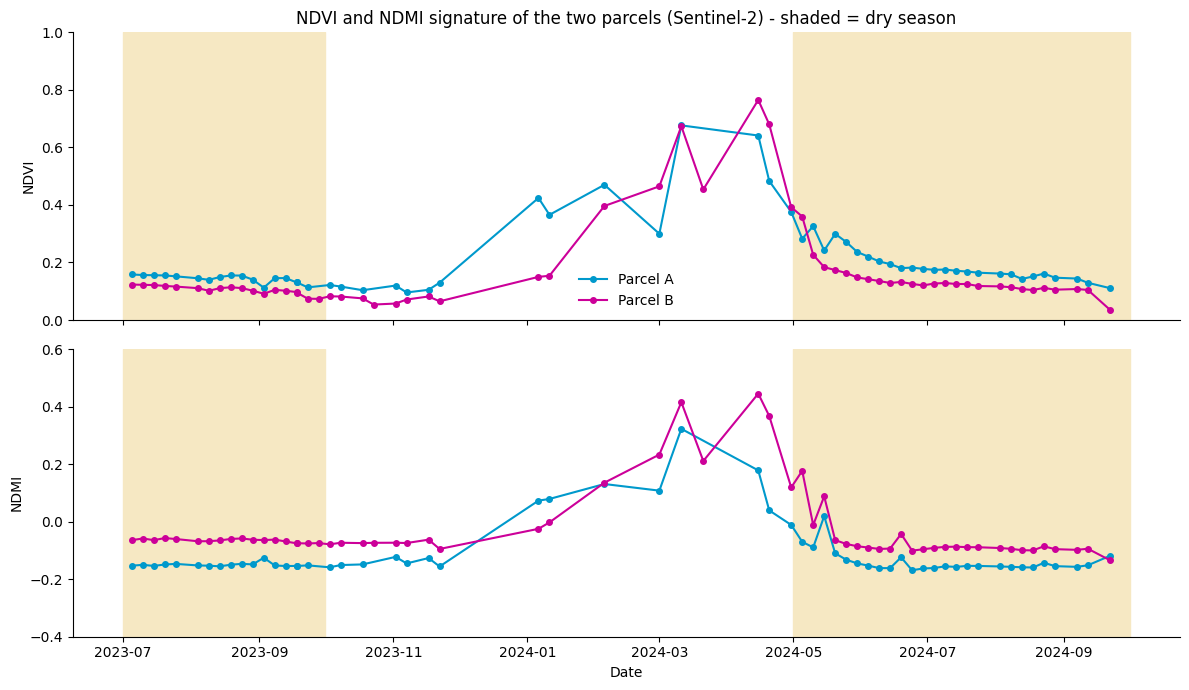

In [53]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for ax, index, limits in [(axes[0], "NDVI", (0, 1)), (axes[1], "NDMI", (-0.4, 0.6))]:
    # Dry seasons shaded
    for start, end in [("2023-07-01", "2023-10-01"), ("2024-05-01", "2024-10-01")]:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color="#f6e8c3", zorder=0)

    ax.plot(series_a.index, series_a[index], marker="o", markersize=4, color="#0099cc", label="Parcel A")
    ax.plot(series_b.index, series_b[index], marker="o", markersize=4, color="#cc0099", label="Parcel B")
    ax.set_ylabel(index)
    ax.set_ylim(*limits)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_title("NDVI and NDMI signature of the two parcels (Sentinel-2) - shaded = dry season")
axes[0].legend(frameon=False)
axes[1].set_xlabel("Date")
plt.tight_layout()
plt.show()

**How to read it.**

- A **rainfed** parcel has **one peak** in the wet season (January - March) and stays low in the
  shaded dry season.
- An **irrigated** parcel stays **green inside the shaded area**, or shows peaks out of phase
  with the rain (e.g. a second cut of alfalfa in July - August).
- A curve that is low all year is fallow land, or a field that was not cultivated that year.
- **NDMI** confirms the water: an irrigated parcel keeps NDMI above its surroundings in the dry
  season; a rainfed one drops to negative values (dry soil and dry stubble).

Decide for A and B before going on. The thresholds of the next step must agree with what you see
here.

### Step 4 - Map algebra: irrigated, rainfed or fallow

Inside the agriculture mask, two Landsat seasonal mosaics and two thresholds:

| Rule | Class |
|---|---|
| NDVI dry > `T_DRY` | **irrigated** (green without rain) |
| NDVI dry ≤ `T_DRY` and NDVI wet > `T_WET` | **rainfed** (green only with rain) |
| otherwise | **fallow / not cultivated** |

In [54]:
# Seasonal NDVI and NDMI of the two parcels (Landsat mosaics of step 2) - to check the thresholds
seasonal = ee.Image.cat([ndvi_dry.rename("NDVI_dry"), ndvi_wet.rename("NDVI_wet"),
                         ndmi_dry.rename("NDMI_dry"), ndmi_wet.rename("NDMI_wet")])

check = pd.DataFrame({
    name: seasonal.reduceRegion(ee.Reducer.mean(), geom, 10).getInfo()
    for name, geom in [("Parcel A", parcel_a), ("Parcel B", parcel_b)]
}).T
check.round(2)

,NDMI_dry,NDMI_wet,NDVI_dry,NDVI_wet
Parcel A,-0.12,0.14,0.19,0.47
Parcel B,-0.07,0.14,0.16,0.40


In [55]:
# >>> Thresholds: adjust them with the signatures and the table above <<<
T_DRY = 0.35     # NDVI in the dry season above this = green without rain
T_WET = 0.30     # NDVI in the wet season above this = crop growing with the rain

# Map algebra: start with 3 (fallow) and overwrite where each rule is true
irrigation = (ee.Image(3)
                .where(ndvi_dry.lte(T_DRY).And(ndvi_wet.gt(T_WET)), 2)   # rainfed
                .where(ndvi_dry.gt(T_DRY), 1)                            # irrigated
                .updateMask(agri)                                        # only agriculture
                .rename("irrigation"))

IRR_NAMES = ["Irrigated", "Rainfed", "Fallow / not cultivated"]
IRR_PALETTE = ["#0571b0", "#e6b800", "#bababa"]
vis_irr = {"min": 1, "max": 3, "palette": IRR_PALETTE}

Map = geemap.Map()
Map.centerObject(IRR_REGION, 13)
Map.add_basemap("SATELLITE")
Map.addLayer(irrigation, vis_irr, "Irrigated / rainfed / fallow")
Map.addLayer(parcel_a, {"color": "cyan"}, "Parcel A")
Map.addLayer(parcel_b, {"color": "magenta"}, "Parcel B")
Map.add_legend(title="Agriculture 2023/24", legend_dict=dict(zip(IRR_NAMES, IRR_PALETTE)))
Map

Map(center=[-16.035936422472712, -68.66615557621901], controls=(WidgetControl(options=['position', 'transparen…

In [56]:
# Area of each type of agriculture (km2)
irr_area = (ee.Image.pixelArea().divide(1e6).addBands(irrigation)
              .reduceRegion(reducer=ee.Reducer.sum().group(groupField=1, groupName="type"),
                            geometry=IRR_REGION, scale=30, maxPixels=1e10))

df_irr = pd.DataFrame(irr_area.getInfo()["groups"]).rename(columns={"sum": "area_km2"})
df_irr["type"] = df_irr["type"].map(dict(zip([1, 2, 3], IRR_NAMES)))
df_irr.round(2)

,area_km2,type
0,4.51,Irrigated
1,29.88,Rainfed
2,2.45,Fallow / not cultivated


> **Limits of the rule.** The thresholds are a simplification: wetlands near the lake, a late
> rainfed crop or a perennial forage can also be green in the dry season. That is why the rule
> must be checked against field knowledge or reference points. Irrigated areas are where ET
> exceeds the rain in the dry season - the water balance of session 4 shows where that water
> must come from.

---

## 3.6 - Change detection with map algebra (MapBiomas)

To detect change we need **two classified maps of the same area** at two dates. Here we use the
MapBiomas maps of **2000** and **2024** to keep the focus on the method. **The logic is exactly the
same with your own classification maps** - classify two (or more) years with the workflow of
sessions 1-3 and apply the same algebra.

### Step 1 - The same legend in both years

MapBiomas has many classes; we group them into 5 broad groups so the change matrix stays readable.

In [57]:
# MapBiomas classes -> 5 groups (codes from the MapBiomas Bolivia legend)
GROUPS = {
    1: [3, 4, 6, 10, 11, 12, 13, 63, 66, 77, 81, 82],     # natural vegetation
    2: [14, 15, 18, 21, 39, 40, 72],                       # farming (agriculture + pasture)
    3: [26, 31, 33, 34],                                   # water
    4: [24],                                               # urban
    5: [22, 23, 25, 29, 30, 61, 68, 92],                   # other non-vegetated
}
GROUP_NAMES = {1: "Natural vegetation", 2: "Farming", 3: "Water", 4: "Urban", 5: "Non-vegetated"}
GROUP_PALETTE = ["#1f8d49", "#ffefc3", "#2532e4", "#d4271e", "#db4d4f"]

# remap needs two flat lists: old codes and new codes
old_codes = [c for codes in GROUPS.values() for c in codes]
new_codes = [g for g, codes in GROUPS.items() for c in codes]


def lulc_groups(year):
    # MapBiomas map of one year, grouped into the 5 classes
    return (mapbiomas.select(f"classification_{year}").clip(IRR_REGION)
              .remap(old_codes, new_codes).rename("group"))


YEAR_1, YEAR_2 = 2000, 2024
lulc_1 = lulc_groups(YEAR_1)
lulc_2 = lulc_groups(YEAR_2)

vis_groups = {"min": 1, "max": 5, "palette": GROUP_PALETTE}
Map = geemap.Map()
Map.centerObject(IRR_REGION, 13)
Map.split_map(left_layer=geemap.ee_tile_layer(lulc_1, vis_groups, str(YEAR_1)),
              right_layer=geemap.ee_tile_layer(lulc_2, vis_groups, str(YEAR_2)),
              left_label=str(YEAR_1), right_label=str(YEAR_2))
Map.add_legend(title="Land use groups", legend_dict=dict(zip(GROUP_NAMES.values(), GROUP_PALETTE)))
Map

Map(center=[-16.035936422472712, -68.66615557621901], controls=(ZoomControl(options=['position', 'zoom_in_text…

### Step 2 - The transition code

One line of map algebra combines the two maps:

$$\text{transition} = \text{class}_{2000} \times 10 + \text{class}_{2024}$$

A pixel that was natural vegetation (1) and became farming (2) gets **12**; a pixel that stayed
farming gets **22**. With the original MapBiomas codes (up to 92) the multiplier would be **100**
instead of 10 - the idea is the same.

In [60]:
# Transition code: first digit = class in YEAR_1, second digit = class in YEAR_2
transition = lulc_1.multiply(10).add(lulc_2).rename("transition")

# Area of every transition (km2), as a "from - to" matrix
trans_area = (ee.Image.pixelArea().divide(1e6).addBands(transition)
                .reduceRegion(reducer=ee.Reducer.sum().group(groupField=1, groupName="code"),
                              geometry=IRR_REGION, scale=30, maxPixels=1e10))

df_trans = pd.DataFrame(trans_area.getInfo()["groups"]).rename(columns={"sum": "area_km2"})
df_trans["from"] = (df_trans["code"] // 10).map(GROUP_NAMES)
df_trans["to"] = (df_trans["code"] % 10).map(GROUP_NAMES)

matrix = df_trans.pivot_table(index="from", columns="to", values="area_km2", fill_value=0)
matrix.round(2)

to,Farming,Natural vegetation,Non-vegetated,Urban,Water
from,,,,,
Farming,15.95,0.84,0.01,0.07,0.03
Natural vegetation,20.79,12.92,0.02,0.15,0.16
Non-vegetated,0.07,0.13,0.06,0.00,0.24
Urban,0.01,0.00,0.00,2.22,0.04
Water,0.01,0.15,0.03,0.01,0.28


**How to read the matrix.** Rows are the class in 2000, columns the class in 2024. The
**diagonal** is what did not change; everything outside the diagonal is change. For example, the
cell *Natural vegetation -> Farming* is the area converted to agriculture or pasture.

### Step 3 - Where did it change?

In [61]:
# Gains of farming and urban between the two years (everything else transparent)
farming_gain = lulc_1.neq(2).And(lulc_2.eq(2)).selfMask()
farming_loss = lulc_1.eq(2).And(lulc_2.neq(2)).selfMask()
urban_gain = lulc_1.neq(4).And(lulc_2.eq(4)).selfMask()

Map = geemap.Map()
Map.centerObject(IRR_REGION, 13)
Map.add_basemap("SATELLITE")
Map.addLayer(farming_gain, {"palette": ["#e6b800"]}, f"Farming gain {YEAR_1}-{YEAR_2}")
Map.addLayer(farming_loss, {"palette": ["#7b3294"]}, f"Farming loss {YEAR_1}-{YEAR_2}")
Map.addLayer(urban_gain, {"palette": ["#d4271e"]}, f"Urban gain {YEAR_1}-{YEAR_2}")
Map.add_legend(title=f"Change {YEAR_1}-{YEAR_2}",
               legend_dict={"Farming gain": "#e6b800", "Farming loss": "#7b3294", "Urban gain": "#d4271e"})
Map

Map(center=[-16.035936422472712, -68.66615557621901], controls=(WidgetControl(options=['position', 'transparen…

---

## 3.7 - Ejercicio / Exercise

1. **K-fold.** Change the block size from 0.003° (~300 m) to 0.006° (~600 m). What happens to the
   gap between random and spatial K-fold?
2. **Thresholds.** Draw two more parcels in the irrigation area, plot their signatures and adjust
   `T_DRY` and `T_WET`. How much does the irrigated area change?
   Then add a second condition with **NDMI dry** (e.g. irrigated = NDVI dry > `T_DRY` **and** NDMI
   dry > 0). Does it remove wetlands or false positives?
3. **Change.** Repeat section 3.6 for 1990 - 2024 and 2010 - 2024. When did most of the farming
   gain happen?
4. **Your own maps.** Classify Copacabana for two years with the workflow of this notebook and
   build the transition matrix with your maps instead of MapBiomas.

**Entregable / Deliverable**: the K-fold table, the exported map, the irrigated / rainfed area and
the change matrix, with a short paragraph on each.

---

## Referencias / References

- Roberts, D. R. et al. (2017). Cross-validation strategies for data with temporal, spatial,
  hierarchical, or phylogenetic structure. *Ecography*, 40(8), 913-929.
  <https://doi.org/10.1111/ecog.02881>
- Olofsson, P. et al. (2014). Good practices for estimating area and assessing accuracy of land
  change. *Remote Sensing of Environment*, 148, 42-57.
  <https://ui.adsabs.harvard.edu/abs/2014RSEnv.148...42O/abstract>
- Ozdogan, M., Yang, Y., Allez, G., Cervantes, C. (2010). Remote sensing of irrigated
  agriculture: opportunities and challenges. *Remote Sensing*, 2(9), 2274-2304.
  <https://doi.org/10.3390/rs2092274>
- Souza, C. M. et al. (2020). Reconstructing three decades of land use and land cover changes in
  Brazilian biomes with Landsat archive and Earth Engine. *Remote Sensing*, 12(17), 2735.
  <https://doi.org/10.3390/rs12172735>
- MapBiomas Bolivia: <https://bolivia.mapbiomas.org>
- scikit-learn - cross-validation: <https://scikit-learn.org/stable/modules/cross_validation.html>
- Earth Engine - exporting images: <https://developers.google.com/earth-engine/guides/exporting_images>